# 02 - Feature Engineering & Selection

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [2]:
from src.data.loader import SessionDataLoader
from src.features.engineering import add_engineered_features, ENGINEERED_FEATURE_NAMES
from src.preprocessing.pipeline import build_preprocessor, get_feature_columns
from src.config.settings import get_settings

settings = get_settings()
df = SessionDataLoader(settings=settings).load()
df = add_engineered_features(df)
df[ENGINEERED_FEATURE_NAMES].describe()

2026-08-10 22:00:35 | INFO     | src.data.loader | Loaded 12000 rows, 18 columns from C:\Desktop\Inernships\Projects\E-Commerce Purchase Intent Prediction using Explainable AI\dataset\ecommerce_sessions.csv
2026-08-10 22:00:35 | INFO     | src.data.loader | Schema validation passed.
2026-08-10 22:00:35 | INFO     | src.features.engineering | Added 6 engineered features: ['total_pages', 'total_duration', 'avg_time_per_page', 'product_page_share', 'product_time_share', 'is_returning_visitor']


,total_pages,total_duration,avg_time_per_page,product_page_share,product_time_share,is_returning_visitor
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,22.266417,778.957263,34.816414,0.873273,0.892281,0.858583
std,13.816705,772.651735,22.305940,0.096376,0.114904,0.348465
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,317.749600,19.860060,0.833333,0.850713,1.000000
50%,19.000000,557.110400,29.065526,0.888889,0.929476,1.000000
75%,28.000000,971.632450,43.311141,0.937500,0.971649,1.000000
max,161.000000,10270.046900,249.644952,1.000000,1.000000,1.000000


## Engineered features

- **total_pages** / **total_duration** — overall engagement depth.
- **avg_time_per_page** — lingering vs. skimming.
- **product_page_share** / **product_time_share** — share of the session actually spent on product pages (count- and time-weighted); an intent proxy that's easy to explain to a CRO stakeholder.
- **is_returning_visitor** — cheap explicit flag many tree models split on early.

# Feature importance - lens 1: model-based (Random Forest)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

feature_cols = get_feature_columns(settings)
X = df[feature_cols]
y = df[settings.data.target]

pre = build_preprocessor(settings)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=settings.seed)

Xt_train = pre.fit_transform(X_train)
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             random_state=settings.seed, n_jobs=-1)
rf.fit(Xt_train, y_train)

feat_names = pre.get_feature_names_out()
importances = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
importances.head(15)

skewed_numeric__PageValues                 0.413516
skewed_numeric__total_pages                0.081593
skewed_numeric__ProductRelated             0.074699
skewed_numeric__ExitRates                  0.069256
skewed_numeric__BounceRates                0.041963
skewed_numeric__total_duration             0.038451
skewed_numeric__ProductRelated_Duration    0.031833
plain_numeric__product_page_share          0.026174
skewed_numeric__avg_time_per_page          0.023980
plain_numeric__product_time_share          0.022762
skewed_numeric__Administrative_Duration    0.021599
skewed_numeric__Informational_Duration     0.012679
skewed_numeric__Administrative             0.011178
skewed_numeric__Informational              0.005137
plain_numeric__SpecialDay                  0.004257
dtype: float64

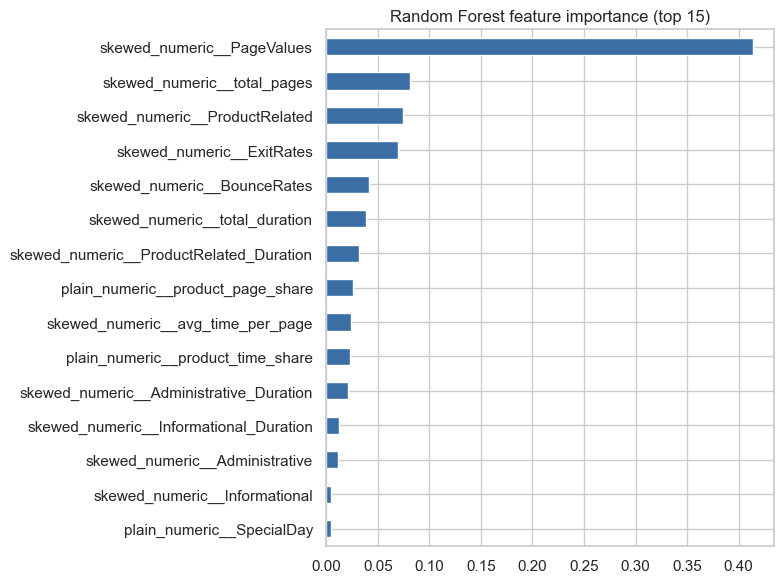

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15)[::-1].plot(kind='barh', ax=ax, color='#3b6ea5')
ax.set_title('Random Forest feature importance (top 15)')
plt.tight_layout()
plt.show()

# Feature importance - lens 2: permutation importance 

In [ ]:
from sklearn.inspection import permutation_importance

Xt_test = pre.transform(X_test)
perm = permutation_importance(rf, Xt_test, y_test, n_repeats=10, 
                             random_state=settings.seed, scoring='average_precision', n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)
perm_series.head(15)